In [1]:
!pip3 install -Uq numpy matplotlib

In [2]:
!pip3 install -Uq einsteinpy scipy 

In [3]:
import numpy as np

In [91]:
def edm_espacio_tiempo(tau, Ys, alpha):
    T, x, y, z, Ut, Ux, Uy, Uz = Ys
    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz

    Apropia = np.array([0, alpha, 0, 0])
    
    # Ultimo cambio
    gamma = Ut
    beta = Ux / gamma
    Lambda = np.array([[gamma, gamma * beta, 0, 0],
                       [gamma * beta, gamma, 0, 0],
                       [0, 0, 1, 0],
                       [0, 0, 0, 1]
    ])
    
    Atierra = Lambda @ Apropia

    dUt_dtau = Atierra[0]
    dUx_dtau = Atierra[1]
    dUy_dtau = Atierra[2]
    dUz_dtau = Atierra[3]
    return np.array([dT_dtau, dx_dtau, dy_dtau, dz_dtau, dUt_dtau, dUx_dtau, dUy_dtau, dUz_dtau])



Unidades relativistas

In [92]:
c_SI = 299792458 # m/s
c = 1 # unidades relativistas
UT = 365.25 * 86400 # segundos en un año
UL = c_SI * UT
UV = UL / UT
UA = UL / UT**2 

### Condiciones iniciales expresadas en coordenadas espaciales y temporales

In [93]:
t = 0
x = 0
y = 0
z = 0

vx = 0
vy = 0
vz = 0

In [94]:
T = c * t
gamma = 1 / np.sqrt(1 - (vx**2 + vy**2 + vz**2) / c**2)
Ut = gamma * c
Ux = gamma * vx
Uy = gamma * vy
Uz = gamma * vz

Y0 = np.array([T, x, y, z, Ut, Ux, Uy, Uz])
Y0

array([0., 0., 0., 0., 1., 0., 0., 0.])

In [95]:
from scipy.integrate import solve_ivp

In [100]:
alpha = 9.8 / UA 
taus = np.linspace(0, 2.2, 100)
solucion = solve_ivp(edm_espacio_tiempo, (taus[0], taus[-1]), Y0, args=(alpha,), t_eval=taus)
solucion

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.222e-02 ...  2.178e+00  2.200e+00]
        y: [[ 0.000e+00  2.222e-02 ...  4.532e+00  4.639e+00]
            [ 0.000e+00  2.547e-04 ...  3.665e+00  3.770e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 38
     njev: 0
      nlu: 0

In [101]:
taus = solucion.t
Ts = solucion.y[0]
xs = solucion.y[1]
ys = solucion.y[2]
zs = solucion.y[3]

Uts = solucion.y[4]
Uxs = solucion.y[5]
Uys = solucion.y[6]
Uzs = solucion.y[7]

Convertir las medidas espacio-temporales en medidas espaciales

In [102]:
ts = Ts / c
gammas = Uts / c
vxs = Uxs / gammas
vys = Uys / gammas
vzs = Uzs / gammas


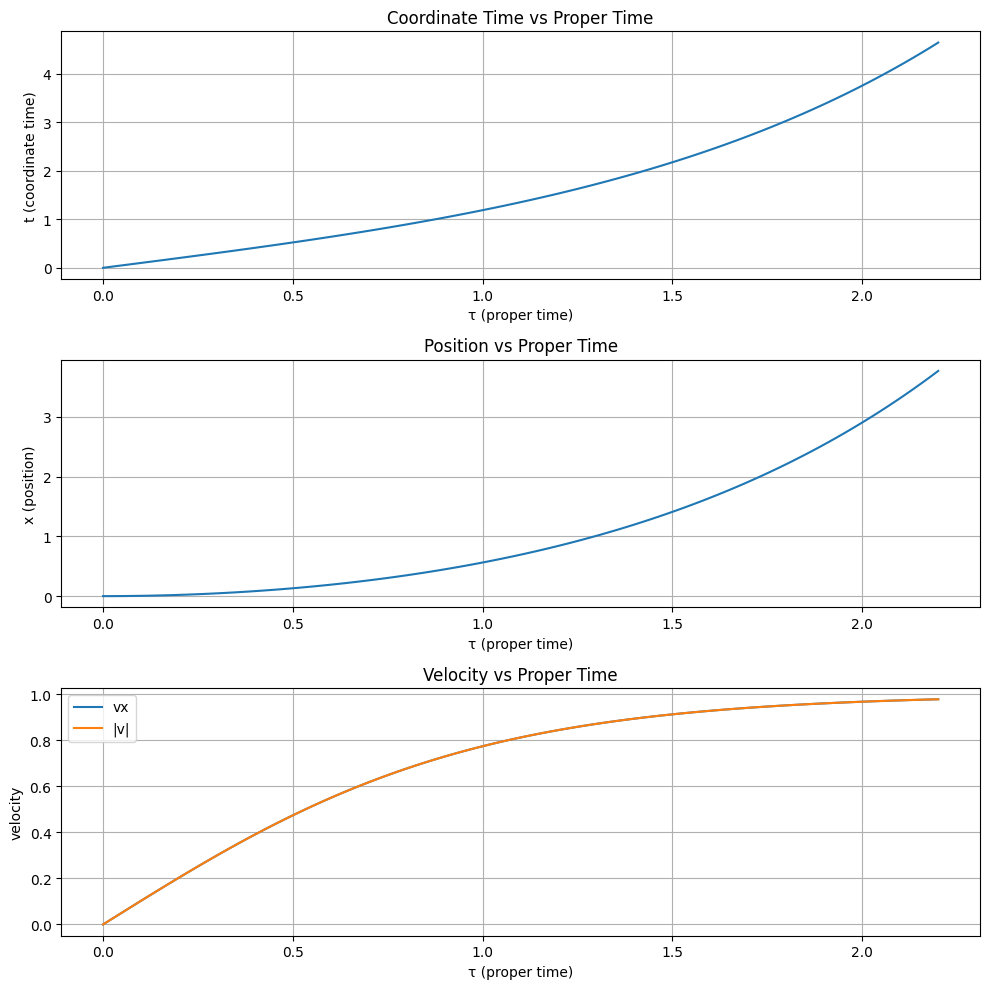

In [103]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# t vs tau
axes[0].plot(taus, ts)
axes[0].set_xlabel('τ (proper time)')
axes[0].set_ylabel('t (coordinate time)')
axes[0].set_title('Coordinate Time vs Proper Time')
axes[0].grid(True)

# x vs tau
axes[1].plot(taus, xs)
axes[1].set_xlabel('τ (proper time)')
axes[1].set_ylabel('x (position)')
axes[1].set_title('Position vs Proper Time')
axes[1].grid(True)

# v vs tau
v_magnitude = np.sqrt(vxs**2 + vys**2 + vzs**2)
axes[2].plot(taus, vxs, label='vx')
axes[2].plot(taus, v_magnitude, label='|v|')
axes[2].set_xlabel('τ (proper time)')
axes[2].set_ylabel('velocity')
axes[2].set_title('Velocity vs Proper Time')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()